# Question 2: Gamma Correction in L\*a\*b\* Color Space

- **(a)** Apply gamma correction to the **L plane** in L\*a\*b\* color space and state the γ value
- **(b)** Show histograms of the original and corrected images

In [1]:
%matplotlib inline
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

## Load the Image

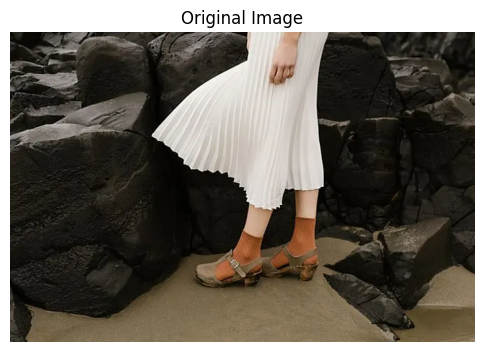

Image shape: (480, 720, 3)


In [2]:
img_bgr = cv.imread('images/feet-shoes-rock.png')
assert img_bgr is not None, "Could not load image. Check the images/ folder."

# Convert BGR -> RGB for display
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

plt.figure(figsize=(6, 5))
plt.imshow(img_rgb)
plt.title('Original Image')
plt.axis('off')
plt.show()
print('Image shape:', img_bgr.shape)

## (a) Gamma Correction on the L Plane in L\*a\*b\* Color Space

**Why L\*a\*b\*?**  
In L\*a\*b\*, the **L channel** represents lightness (0=black, 100=white), completely separated from color (a\*, b\* channels). Applying gamma only to L lets us adjust brightness **without shifting the colors** of the image.

**Why γ = 0.5?**  
The image has large dark regions (black rocks). γ < 1 brightens the dark areas, revealing more detail while keeping the bright regions (white dress) from being overexposed.

L channel — min: 0  max: 255  dtype: uint8


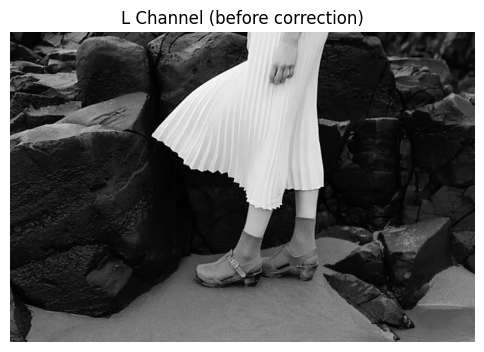

In [3]:
# Convert BGR --> L*a*b*
img_lab = cv.cvtColor(img_bgr, cv.COLOR_BGR2Lab)

# Split into L, a, b channels
L, a, b = cv.split(img_lab)

print('L channel — min:', L.min(), ' max:', L.max(), ' dtype:', L.dtype)

# In OpenCV, L is stored in range [0, 255] (scaled from [0, 100])
# Visualise the L channel before correction
plt.figure(figsize=(6, 5))
plt.imshow(L, cmap='gray')
plt.title('L Channel (before correction)')
plt.axis('off')
plt.show()

Gamma applied: γ = 0.5
L corrected — min: 0  max: 255


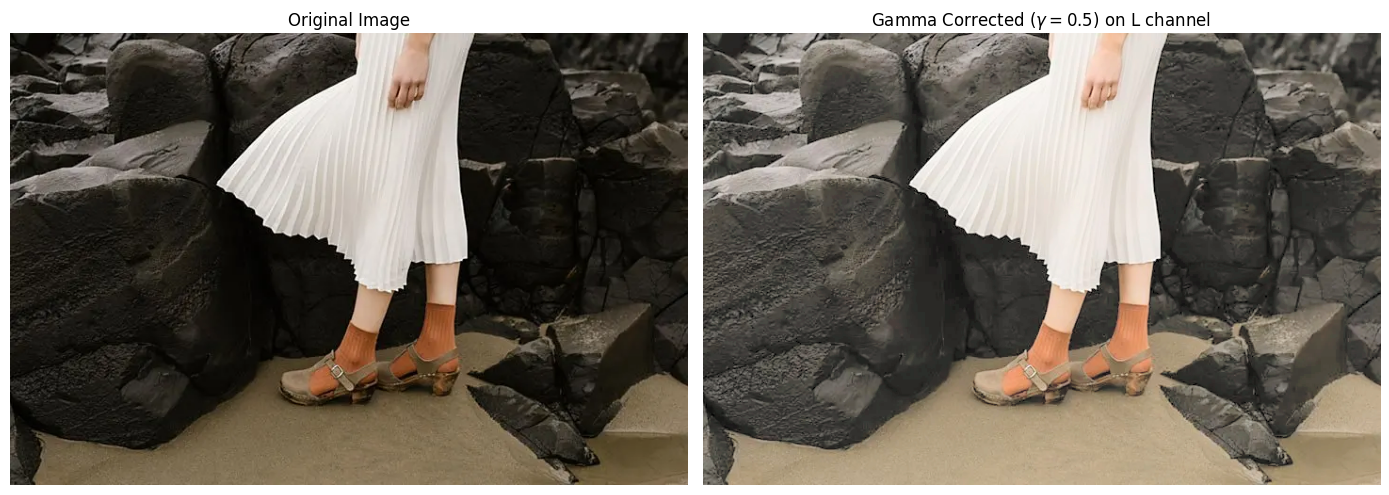

In [4]:
# Apply gamma correction to L channel
gamma = 0.5   # γ < 1 brightens the image; chosen to lift the dark rock regions

# Build LUT on [0, 255] range
lut = np.array([(i / 255.0) ** gamma * 255 for i in range(256)], dtype=np.uint8)
L_corrected = cv.LUT(L, lut)

print(f'Gamma applied: γ = {gamma}')
print('L corrected — min:', L_corrected.min(), ' max:', L_corrected.max())

# Merge corrected L back with original a, b channels
img_lab_corrected = cv.merge([L_corrected, a, b])

# Convert back to BGR then RGB for display
img_corrected_bgr = cv.cvtColor(img_lab_corrected, cv.COLOR_Lab2BGR)
img_corrected_rgb = cv.cvtColor(img_corrected_bgr, cv.COLOR_BGR2RGB)

# Display original vs corrected
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(img_rgb)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(img_corrected_rgb)
axes[1].set_title(rf'Gamma Corrected ($\gamma={gamma}$) on L channel')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('output/q2a_gamma_corrected.png', dpi=150, bbox_inches='tight')
plt.show()

## (b) Histograms of Original and Corrected Images

We plot histograms of the **L channel** before and after correction to clearly show how gamma shifts the intensity distribution.

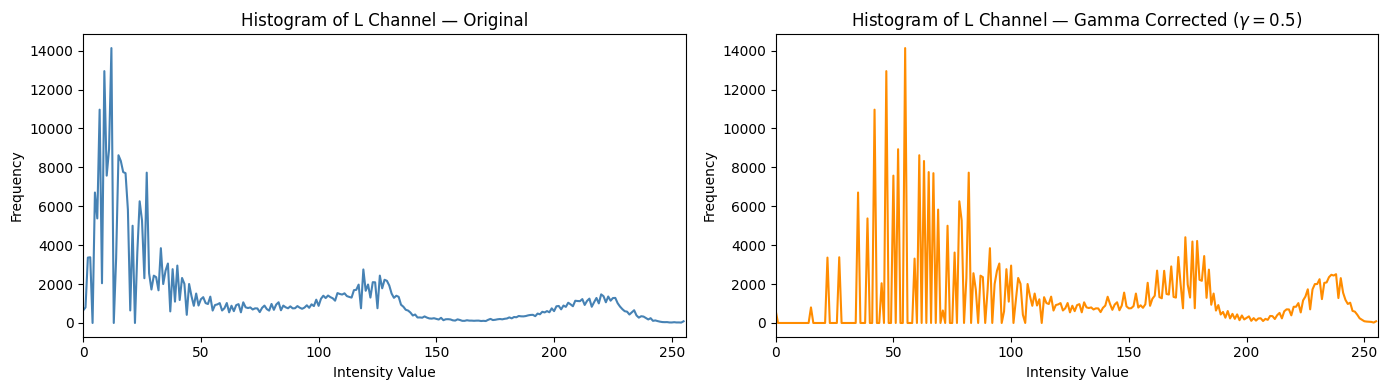

In [5]:
# Histograms of the L channel: before vs after
hist_orig = cv.calcHist([L], [0], None, [256], [0, 256])
hist_corr = cv.calcHist([L_corrected], [0], None, [256], [0, 256])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(hist_orig, color='steelblue')
axes[0].set_title('Histogram of L Channel — Original')
axes[0].set_xlabel('Intensity Value')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim([0, 256])

axes[1].plot(hist_corr, color='darkorange')
axes[1].set_title(rf'Histogram of L Channel — Gamma Corrected ($\gamma={gamma}$)')
axes[1].set_xlabel('Intensity Value')
axes[1].set_ylabel('Frequency')
axes[1].set_xlim([0, 256])

plt.tight_layout()
plt.savefig('output/q2b_histograms_L.png', dpi=150, bbox_inches='tight')
plt.show()

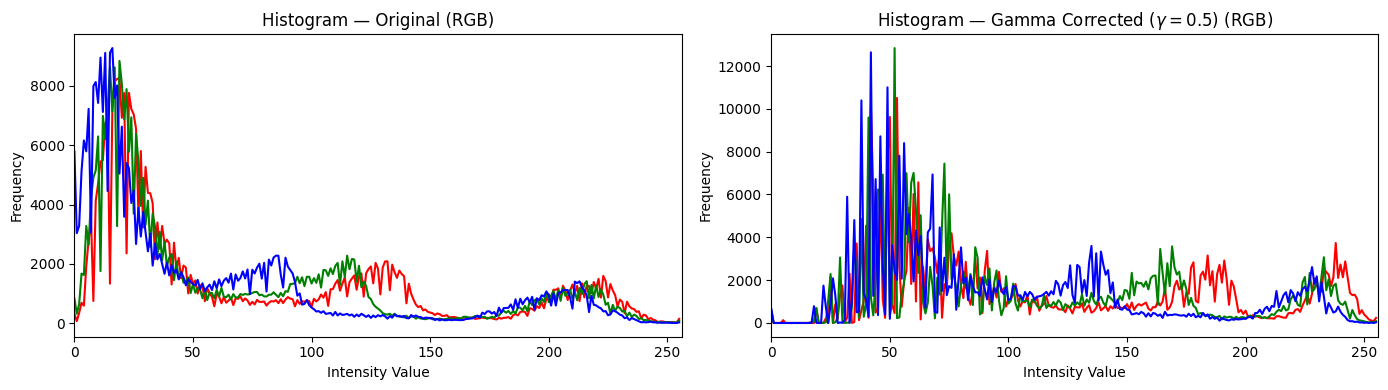

In [6]:
# Histograms of the full RGB images: before vs after
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors = ('r', 'g', 'b')

for i, c in enumerate(colors):
    hist_o = cv.calcHist([img_rgb], [i], None, [256], [0, 256])
    hist_c = cv.calcHist([img_corrected_rgb], [i], None, [256], [0, 256])
    axes[0].plot(hist_o, color=c)
    axes[1].plot(hist_c, color=c)

axes[0].set_title('Histogram — Original (RGB)')
axes[0].set_xlabel('Intensity Value')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim([0, 256])

axes[1].set_title(rf'Histogram — Gamma Corrected ($\gamma={gamma}$) (RGB)')
axes[1].set_xlabel('Intensity Value')
axes[1].set_ylabel('Frequency')
axes[1].set_xlim([0, 256])

plt.tight_layout()
plt.savefig('output/q2b_histograms_RGB.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

| | |
|---|---|
| **Color space used** | L\*a\*b\* |
| **Channel corrected** | L (lightness) only |
| **γ value chosen** | 0.5 |
| **Effect** | Dark rock regions are brightened; colors (a\*, b\*) are unchanged |
| **Histogram shift** | Distribution shifts to the right (higher intensities) after correction |